# GRPO evaluation — definitive results package

Loads **saved artifacts only** (no training, no inference). All NuminaMath cross-benchmark metrics use the **corrected checkpoint scorer** (`evaluation/checkpoints/`), not legacy `evaluation/summary.json`.

## A. Evaluation setup

| Item | Detail |
|------|--------|
| **Base model** | `Qwen/Qwen2-0.5B-Instruct` |
| **GRPO model** | LoRA adapters, final save `checkpoints/Qwen2-0.5B-GRPO` (checkpoint step **905**) |
| **Training data** | `AI-MO/NuminaMath-TIR` train slice (`train[:5%]`) used for GRPO + LoRA post-training |
| **NuminaMath eval** | Held-out **test** split, **n=99** (full test subset); Base = **step 0**, GRPO = **checkpoint-905** from `evaluation/checkpoints/summary.json` |
| **GSM8K** | `openai/gsm8k` test, **n=500** — `evaluation/gsm8k/summary.json` |
| **MATH-500** | `HuggingFaceH4/MATH-500` test, **n=500** — `evaluation/math500/summary.json` |
| **Decoding** | Greedy / deterministic, one completion per problem |
| **Max generation** | 256 new tokens; identical system prompt and chat template for Base and GRPO |
| **Scoring** | Math and format scored separately; `<answer>` block used when present, else fallback parsing; `math_verify` + numeric fallback; empty gold never counts as correct |

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CANDIDATES = [
    Path("/global/cfs/cdirs/m3560/Partha/GRPO/evaluation"),
    Path.cwd() / "evaluation",
    Path.cwd(),
]
EVAL = next((p for p in CANDIDATES if (p / "checkpoints" / "summary.json").is_file()), CANDIDATES[0])
PLOTS = EVAL / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

SAMPLE_SIZES = {"NuminaMath": 99, "GSM8K": 500, "MATH-500": 500}
FINAL_GRPO_STEP = 905
COLORS = {"Base": "#4C72B0", "GRPO": "#DD8452"}
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


def load_json(path: Path) -> dict:
    with path.open() as f:
        return json.load(f)


def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple[float, float, float]:
    """Return (p_hat, lower, upper) for proportion k/n."""
    if n <= 0:
        return 0.0, 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * math.sqrt((p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return p, max(0.0, center - margin), min(1.0, center + margin)


def row_to_metrics(row: dict) -> dict:
    return {
        "math_accuracy": row["math_accuracy"],
        "format_compliance": row["format_compliance"],
        "strict_success": row["strict_success"],
        "parse_failure_rate": row["parse_failure_rate"],
        "avg_generated_tokens": row["avg_generated_tokens"],
        "median_generated_tokens": row["median_generated_tokens"],
        "fraction_clipped_at_max": row["fraction_clipped_at_max"],
    }


def numina_summary_from_checkpoints(ckpt: dict) -> dict:
    by_step = {int(r["step"]): r for r in ckpt["checkpoints"]}
    if 0 not in by_step or FINAL_GRPO_STEP not in by_step:
        raise ValueError("Checkpoint summary must include steps 0 and 905")
    return {
        "benchmark": "numina_test_checkpoints",
        "n_examples": ckpt["n_examples"],
        "artifact": str(EVAL / "checkpoints" / "summary.json"),
        "base": row_to_metrics(by_step[0]),
        "grpo": row_to_metrics(by_step[FINAL_GRPO_STEP]),
    }


ckpt = load_json(EVAL / "checkpoints" / "summary.json")
gsm8k = load_json(EVAL / "gsm8k" / "summary.json")
math500 = load_json(EVAL / "math500" / "summary.json")
numina = numina_summary_from_checkpoints(ckpt)

BENCHMARKS = {
    "NuminaMath": numina,
    "GSM8K": gsm8k,
    "MATH-500": math500,
}

# Consistency guard: refuse legacy Numina table
legacy_path = EVAL / "summary.json"
if legacy_path.is_file():
    legacy = load_json(legacy_path)
    leg_acc = legacy["base"]["math_accuracy"]
    corr_acc = numina["base"]["math_accuracy"]
    if abs(leg_acc - corr_acc) > 0.02:
        print(
            f"NOTE: legacy evaluation/summary.json base math={100*leg_acc:.1f}% "
            f"is NOT used; corrected checkpoint base math={100*corr_acc:.1f}%."
        )

NOTE: legacy evaluation/summary.json base math=1.0% is NOT used; corrected checkpoint base math=6.1%.


In [2]:
def proportion_counts_from_jsonl(
    path: Path,
    *,
    acc_key: str,
    fmt_key: str,
    fmt_threshold: float = 1.0,
) -> tuple[int, int, int]:
    rows = load_jsonl(path)
    n = len(rows)
    k_acc = sum(1 for r in rows if r[acc_key])
    k_fmt = sum(1 for r in rows if float(r[fmt_key]) >= fmt_threshold)
    return k_acc, k_fmt, n


def proportion_counts_numina_ckpt(label: str) -> tuple[int, int, int]:
    path = EVAL / "checkpoints" / f"{label}_per_example.jsonl"
    rows = load_jsonl(path)
    n = len(rows)
    k_acc = sum(1 for r in rows if r["math_accuracy"])
    k_fmt = sum(1 for r in rows if float(r["format_compliance"]) >= 1.0)
    return k_acc, k_fmt, n


CI: dict[tuple[str, str, str], tuple[float, float, float]] = {}
k_acc, k_fmt, n = proportion_counts_numina_ckpt("base")
CI[("NuminaMath", "Base", "math")] = wilson_ci(k_acc, n)
CI[("NuminaMath", "Base", "format")] = wilson_ci(k_fmt, n)
k_acc, k_fmt, n = proportion_counts_numina_ckpt("checkpoint-905")
CI[("NuminaMath", "GRPO", "math")] = wilson_ci(k_acc, n)
CI[("NuminaMath", "GRPO", "format")] = wilson_ci(k_fmt, n)

for bench, path, ak, fk in [
    ("GSM8K", EVAL / "gsm8k" / "per_example.jsonl", "base_accuracy", "base_format"),
    ("GSM8K", EVAL / "gsm8k" / "per_example.jsonl", "grpo_accuracy", "grpo_format"),
    ("MATH-500", EVAL / "math500" / "per_example.jsonl", "base_accuracy", "base_format"),
    ("MATH-500", EVAL / "math500" / "per_example.jsonl", "grpo_accuracy", "grpo_format"),
]:
    rows = load_jsonl(path)
    n = len(rows)
    k_acc = sum(1 for r in rows if r[ak])
    k_fmt = sum(1 for r in rows if float(r[fk]) >= 1.0)
    model = "Base" if ak.startswith("base") else "GRPO"
    CI[(bench, model, "math")] = wilson_ci(k_acc, n)
    CI[(bench, model, "format")] = wilson_ci(k_fmt, n)


def bench_frame() -> pd.DataFrame:
    rows = []
    for name, s in BENCHMARKS.items():
        for model_key, model_label in (("base", "Base"), ("grpo", "GRPO")):
            m = s[model_key]
            rows.append(
                {
                    "Benchmark": name,
                    "Model": model_label,
                    "n": s["n_examples"],
                    "Math Accuracy": m["math_accuracy"],
                    "Format Compliance": m["format_compliance"],
                    "Strict Success": m["strict_success"],
                    "Parse Failure": m["parse_failure_rate"],
                    "Avg Tokens": m["avg_generated_tokens"],
                    "Median Tokens": m["median_generated_tokens"],
                    "Clipped Rate": m["fraction_clipped_at_max"],
                }
            )
    return pd.DataFrame(rows)


df = bench_frame()


def pct(x: float) -> str:
    return f"{100 * x:.1f}%"


def ci_str(bench: str, model: str, metric: str) -> str:
    p, lo, hi = CI[(bench, model, metric)]
    return f"{100*p:.1f}% [{100*lo:.1f}, {100*hi:.1f}]"


print("Corrected NuminaMath (checkpoint scorer):")
print("  Base step 0:", {k: pct(v) for k, v in numina["base"].items() if k in ("math_accuracy", "format_compliance", "strict_success")})
print("  GRPO step 905:", {k: pct(v) for k, v in numina["grpo"].items() if k in ("math_accuracy", "format_compliance", "strict_success")})

Corrected NuminaMath (checkpoint scorer):
  Base step 0: {'math_accuracy': '6.1%', 'format_compliance': '1.0%', 'strict_success': '0.0%'}
  GRPO step 905: {'math_accuracy': '6.1%', 'format_compliance': '16.2%', 'strict_success': '1.0%'}


## B–D. Final cross-benchmark plots (with 95% Wilson intervals on math & format)

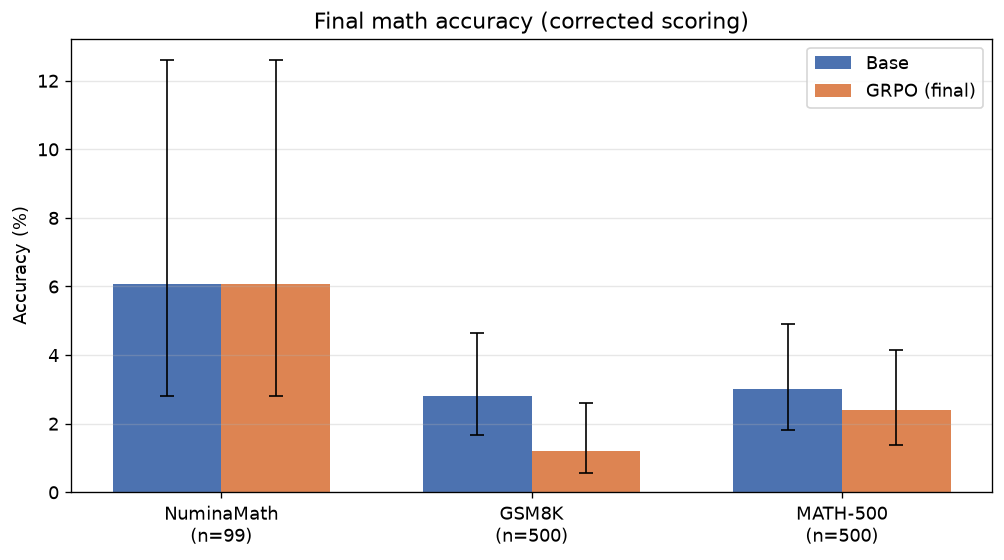

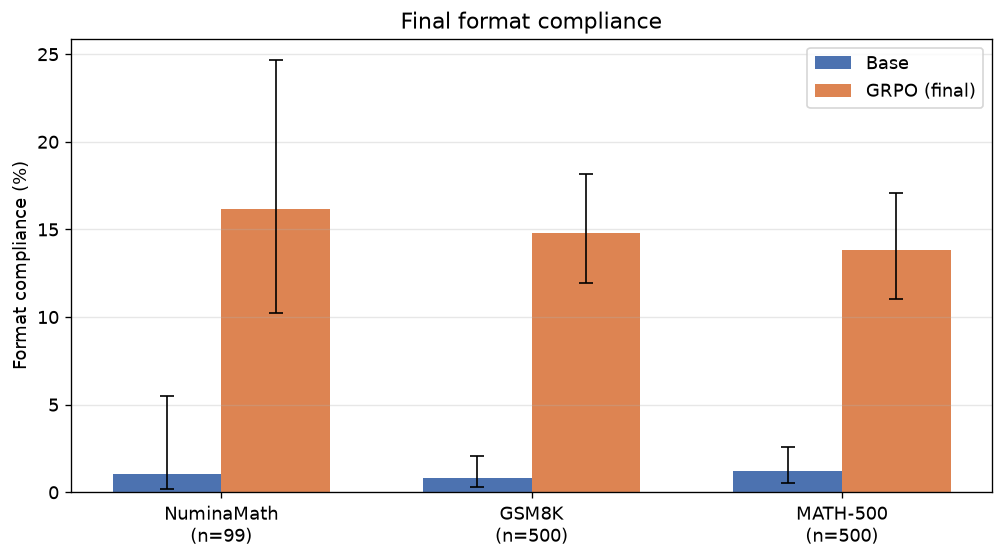

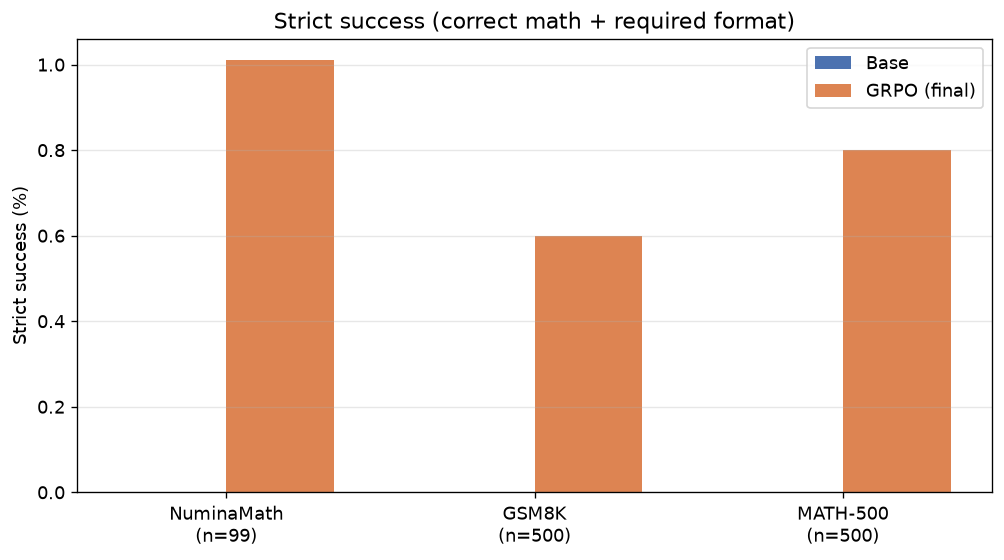

In [3]:
def benchmark_grouped_bar(
    metric_key: str,
    ci_metric: str | None,
    title: str,
    ylabel: str,
    outfile: Path,
) -> None:
    names = list(BENCHMARKS.keys())
    x = list(range(len(names)))
    width = 0.35
    base_vals = [100 * BENCHMARKS[n]["base"][metric_key] for n in names]
    grpo_vals = [100 * BENCHMARKS[n]["grpo"][metric_key] for n in names]

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.bar([i - width / 2 for i in x], base_vals, width, label="Base", color=COLORS["Base"])
    ax.bar([i + width / 2 for i in x], grpo_vals, width, label="GRPO (final)", color=COLORS["GRPO"])

    if ci_metric is not None:
        for i, bench in enumerate(names):
            for offset, model, vals in [
                (-width / 2, "Base", base_vals),
                (width / 2, "GRPO", grpo_vals),
            ]:
                p, lo, hi = CI[(bench, model, ci_metric)]
                yerr = [[100 * (p - lo)], [100 * (hi - p)]]
                ax.errorbar(i + offset, 100 * p, yerr=yerr, fmt="none", ecolor="black", capsize=4, linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{n}\n(n={SAMPLE_SIZES[n]})" for n in names])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(outfile, bbox_inches="tight")
    plt.show()


benchmark_grouped_bar(
    "math_accuracy",
    "math",
    "Final math accuracy (corrected scoring)",
    "Accuracy (%)",
    PLOTS / "final_math_accuracy.png",
)
benchmark_grouped_bar(
    "format_compliance",
    "format",
    "Final format compliance",
    "Format compliance (%)",
    PLOTS / "final_format_compliance.png",
)
benchmark_grouped_bar(
    "strict_success",
    None,
    "Strict success (correct math + required format)",
    "Strict success (%)",
    PLOTS / "final_strict_success.png",
)

## E. NuminaMath checkpoint learning curve

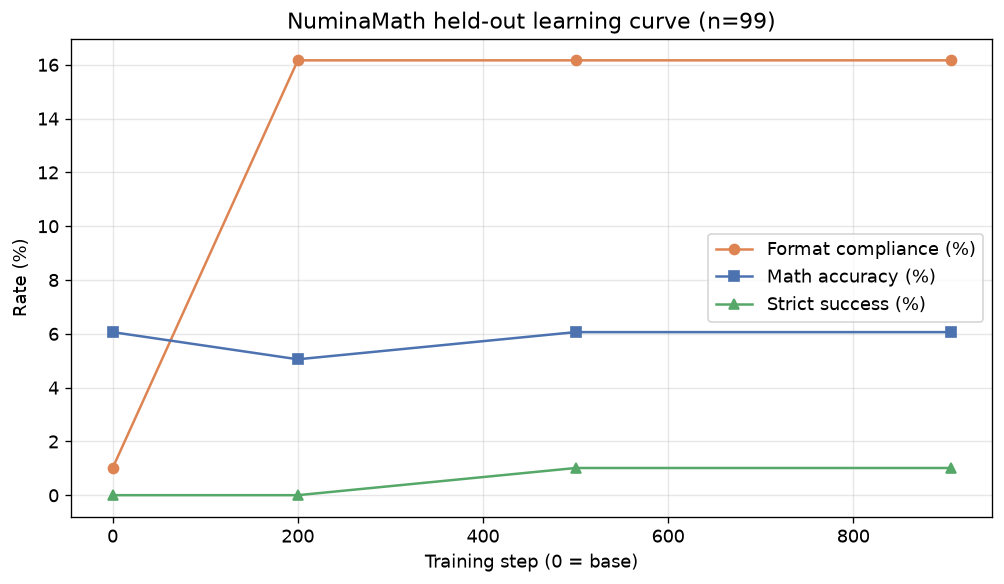

,step,math_accuracy,format_compliance,strict_success,parse_failure_rate
0,0,0.060606,0.010101,0.000000,0.545455
1,200,0.050505,0.161616,0.000000,0.545455
2,500,0.060606,0.161616,0.010101,0.565657
3,905,0.060606,0.161616,0.010101,0.555556


In [4]:
curve = pd.DataFrame(ckpt["checkpoints"]).sort_values("step")
steps = curve["step"].tolist()
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(steps, 100 * curve["format_compliance"], marker="o", label="Format compliance (%)", color="#DD8452")
ax.plot(steps, 100 * curve["math_accuracy"], marker="s", label="Math accuracy (%)", color="#4C72B0")
ax.plot(steps, 100 * curve["strict_success"], marker="^", label="Strict success (%)", color="#55A868")
ax.set_xlabel("Training step (0 = base)")
ax.set_ylabel("Rate (%)")
ax.set_title(f"NuminaMath held-out learning curve (n={SAMPLE_SIZES['NuminaMath']})")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS / "final_checkpoint_learning_curve.png", bbox_inches="tight")
plt.show()
curve[["step", "math_accuracy", "format_compliance", "strict_success", "parse_failure_rate"]]

## F. Generation behavior (GSM8K & MATH-500)

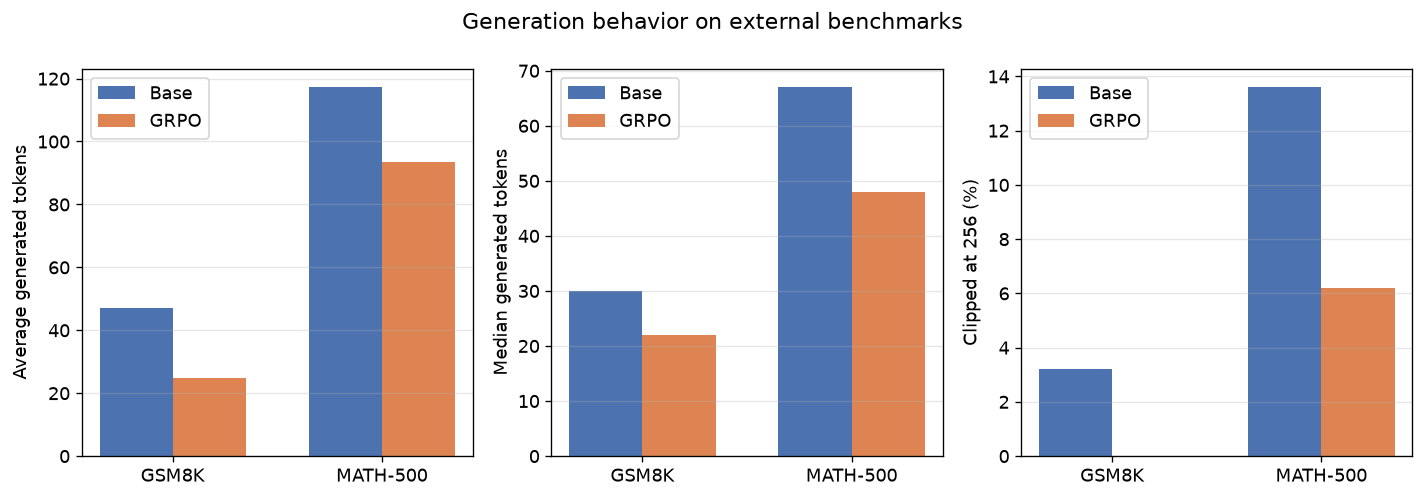

In [5]:
ext = df[df["Benchmark"].isin(["GSM8K", "MATH-500"])].copy()
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, col, ylab, as_pct in [
    (axes[0], "Avg Tokens", "Average generated tokens", False),
    (axes[1], "Median Tokens", "Median generated tokens", False),
    (axes[2], "Clipped Rate", "Clipped at 256 (%)", True),
]:
    pivot = ext.pivot(index="Benchmark", columns="Model", values=col)
    if as_pct:
        pivot = 100 * pivot
    x = list(range(len(pivot.index)))
    width = 0.35
    ax.bar([i - width / 2 for i in x], pivot["Base"], width, label="Base", color=COLORS["Base"])
    ax.bar([i + width / 2 for i in x], pivot["GRPO"], width, label="GRPO", color=COLORS["GRPO"])
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index)
    ax.set_ylabel(ylab)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
fig.suptitle("Generation behavior on external benchmarks")
fig.tight_layout()
fig.savefig(PLOTS / "final_generation_behavior.png", bbox_inches="tight")
plt.show()

## G. Final summary table

In [6]:
summary_table = df[
    [
        "Benchmark",
        "Model",
        "Math Accuracy",
        "Format Compliance",
        "Strict Success",
        "Parse Failure",
        "Avg Tokens",
        "Median Tokens",
        "Clipped Rate",
    ]
].copy()
for col in ["Math Accuracy", "Format Compliance", "Strict Success", "Parse Failure", "Clipped Rate"]:
    summary_table[col] = summary_table[col].map(pct)
summary_table

,Benchmark,Model,Math Accuracy,Format Compliance,Strict Success,Parse Failure,Avg Tokens,Median Tokens,Clipped Rate
0,NuminaMath,Base,6.1%,1.0%,0.0%,54.5%,71.484848,48.0,7.1%
1,NuminaMath,GRPO,6.1%,16.2%,1.0%,55.6%,46.111111,40.0,0.0%
2,GSM8K,Base,2.8%,0.8%,0.0%,41.2%,47.054000,30.0,3.2%
3,GSM8K,GRPO,1.2%,14.8%,0.6%,41.2%,24.800000,22.0,0.0%
4,MATH-500,Base,3.0%,1.2%,0.0%,63.2%,117.264000,67.0,13.6%
5,MATH-500,GRPO,2.4%,13.8%,0.8%,63.2%,93.626000,48.0,6.2%


In [7]:
ci_table = []
for bench in BENCHMARKS:
    for model in ("Base", "GRPO"):
        ci_table.append(
            {
                "Benchmark": bench,
                "Model": model,
                "Math 95% Wilson CI": ci_str(bench, model, "math"),
                "Format 95% Wilson CI": ci_str(bench, model, "format"),
            }
        )
pd.DataFrame(ci_table)

,Benchmark,Model,Math 95% Wilson CI,Format 95% Wilson CI
0,NuminaMath,Base,"6.1% [2.8, 12.6]","1.0% [0.2, 5.5]"
1,NuminaMath,GRPO,"6.1% [2.8, 12.6]","16.2% [10.2, 24.7]"
2,GSM8K,Base,"2.8% [1.7, 4.6]","0.8% [0.3, 2.0]"
3,GSM8K,GRPO,"1.2% [0.6, 2.6]","14.8% [12.0, 18.2]"
4,MATH-500,Base,"3.0% [1.8, 4.9]","1.2% [0.6, 2.6]"
5,MATH-500,GRPO,"2.4% [1.4, 4.1]","13.8% [11.1, 17.1]"


## Consistency check

In [8]:
checks = []
checks.append(("Numina base math != legacy ~1%", numina["base"]["math_accuracy"] > 0.03))
checks.append(("Numina uses n=99", numina["n_examples"] == 99))
checks.append(("GSM8K n=500", gsm8k["n_examples"] == 500))
checks.append(("MATH-500 n=500", math500["n_examples"] == 500))
for bench, s in BENCHMARKS.items():
    for side in ("base", "grpo"):
        m = s[side]
        plot_val = 100 * m["math_accuracy"]
        label = "GRPO" if side == "grpo" else "Base"
        table_val = 100 * df[(df["Benchmark"] == bench) & (df["Model"] == label)]["Math Accuracy"].iloc[0]
        checks.append((f"{bench} {label} table/plot math match", abs(plot_val - table_val) < 1e-6))

for msg, ok in checks:
    print(("PASS" if ok else "FAIL"), msg)
if not all(ok for _, ok in checks):
    raise RuntimeError("Consistency check failed")

PASS Numina base math != legacy ~1%
PASS Numina uses n=99
PASS GSM8K n=500
PASS MATH-500 n=500
PASS NuminaMath Base table/plot math match
PASS NuminaMath GRPO table/plot math match
PASS GSM8K Base table/plot math match
PASS GSM8K GRPO table/plot math match
PASS MATH-500 Base table/plot math match
PASS MATH-500 GRPO table/plot math match


## Final interpretation

- **Formatting:** GRPO improves format compliance on all three benchmarks (Numina from corrected checkpoint step 905 vs base step 0; GSM8K and MATH-500 from saved summaries). Wilson intervals for format are narrow enough to treat this as a real effect.
- **Mathematical correctness:** No improvement — Numina math accuracy is flat between base and final checkpoint; GSM8K and MATH-500 math accuracy is equal or lower under GRPO. Overlapping Wilson intervals mean small deltas should not be over-interpreted.
- **Generalization:** No evidence of improved external math reasoning on GSM8K or MATH-500; gains are primarily template/format alignment.
- **Checkpoint behavior:** Format compliance rises by step 200 and plateaus; math accuracy stays roughly flat across steps 0→905.
- **Generation behavior:** GRPO tends to produce shorter completions and lower clipping rates on GSM8K/MATH-500; reported examples/sec differences reflect shorter outputs and evaluation harness timing, not a claim of architectural speedup.

**Do not claim GRPO improved reasoning** based on these results.